# CNN Classification Model to Investigate Cell Image Types

### Importing required libraries

In [1]:
import pickle
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision
import torchvision.transforms as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import numpy as np
from tqdm import tqdm
import seaborn as sns
import torchvision.models as models

ModuleNotFoundError: No module named 'torchvision'

### Setting up the GPU Device

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda:0


### Setting the seed for reproducibility

In [3]:
SEED = 35  # Random seed for reproducibility

In [4]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(False)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

## Data Preparation

### Extracting labels and determining number of classes

In [5]:
# Configuration

pkl_directory = "imaging/dataset_extraction/cell_dataset/" # The PKL Directory
TARGET_H, TARGET_W = 224, 224  # Target dimension of 224 for resizing images - it is the standard for ResNet
USE_GRAYSCALE = False  # Whether to use grayscale images
BATCH_SIZE = 64  # Batch size for training
NUM_WORKERS = 4

In [6]:
cell_labels = []
cell_images = []
for pkl_file in Path(pkl_directory).glob("*.pkl"):
   with open(pkl_file, "rb") as f:
      entry = pickle.load(f)

   cell_labels.extend(entry["labels"])
   cell_images.extend(entry["data"])

In [7]:
y = np.asarray(cell_labels, dtype=np.int64)
num_classes = int(np.max(y)) + 1
print(f"Number of classes: {num_classes}")

Number of classes: 3


In [8]:
idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]
idx_2 = np.where(y == 2)[0]
target_n = min(len(idx_0), len(idx_1), len(idx_2))

rng = np.random.default_rng(SEED)
selected_idx_0 = rng.choice(idx_0, size=target_n, replace=False)
selected_idx_1 = rng.choice(idx_1, size=target_n, replace=False)
selected_idx_2 = rng.choice(idx_2, size=target_n, replace=False)

selected_indices = np.concatenate([selected_idx_0, selected_idx_1, selected_idx_2])
rng.shuffle(selected_indices)
X = [cell_images[i] for i in selected_indices]
y = y[selected_indices]

In [9]:
print(f"Total samples after balancing: {len(X)}")

Total samples after balancing: 19866


### Defining the Dataset class and Building the Dataset

In [10]:
class CellsDataset(Dataset):
    def __init__(self, images, labels, transform=None, grayscale=USE_GRAYSCALE):
        self.images = images
        self.labels = labels
        self.transform = transform

        base = []
        base += [T.ToPILImage()]
        base += [T.Resize((TARGET_H, TARGET_W), antialias=True)]
        
        if grayscale:
            base += [T.Grayscale(num_output_channels=1)]
        
        if self.transform:
            base += [
                T.RandomHorizontalFlip(p = 0.5),
                T.RandomVerticalFlip(p = 0.3),
            ]
        
        base += [T.ToTensor()]
        base += [T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])] # ImageNet normalization
        self.to_tensor = T.Compose(base)
    
        
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        if self.transform is not None:
            image = self.to_tensor(image)
        y = int(self.labels[idx])
        return image, y

In [11]:
# Stratified Split into Train, Validation, and Test Sets (Stratification helps maintain class distribution across splits)

idx = np.arange(len(y))
train_idx, temp_idx, y_train, y_temp = train_test_split(idx, y, test_size=0.3, random_state=SEED, stratify=y)
val_idx, test_idx, y_val, y_test = train_test_split(temp_idx, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

In [12]:
# Defining the datasets

train_dataset = CellsDataset(
    images=[X[i] for i in train_idx],
    labels=y_train,
    transform=True,
    grayscale=USE_GRAYSCALE
)

val_dataset = CellsDataset(
    images=[X[i] for i in val_idx],
    labels=y_val,
    transform=False,
    grayscale=USE_GRAYSCALE
)

test_dataset = CellsDataset(
    images=[X[i] for i in test_idx],
    labels=y_test,
    transform=False,
    grayscale=USE_GRAYSCALE
)

In [13]:
# Using a WeightedRandomSampler to handle class imbalance in the training dataset
class_counts = Counter(y_train)
class_weights = torch.tensor([1.0 / class_counts[i] for i in range(num_classes)], dtype=torch.float)
sample_weights = torch.tensor([class_weights[label] for label in y_train], dtype=torch.float)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

In [14]:
# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [15]:
print("Train Counts:", Counter(y_train))
print("Validation Counts:", Counter(y_val))
print("Test Counts:", Counter(y_test))

Train Counts: Counter({np.int64(0): 4636, np.int64(1): 4635, np.int64(2): 4635})
Validation Counts: Counter({np.int64(1): 994, np.int64(0): 993, np.int64(2): 993})
Test Counts: Counter({np.int64(2): 994, np.int64(0): 993, np.int64(1): 993})


## Model Definition

In [16]:
weights = models.VGG16_Weights.IMAGENET1K_V1
model = models.vgg16(weights=weights)

in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, num_classes)
model = model.to(device)

In [17]:
def print_metrics(y_true, y_pred, label=""):
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0, 1, 2])
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    print(f"\n{label} metrics:")
    for cls in [0, 1, 2]:
        tp = ((y_true == cls) & (y_pred == cls)).sum()
        fp = ((y_true != cls) & (y_pred == cls)).sum()
        fn = ((y_true == cls) & (y_pred != cls)).sum()
        print(f"Class {cls}:")
        print(f"  TP={tp}, FP={fp}, FN={fn}")
        print(f"  Precision = TP / (TP + FP) = {tp} / ({tp} + {fp}) = {precision[cls]:.4f}")
        print(f"  Recall    = TP / (TP + FN) = {tp} / ({tp} + {fn}) = {recall[cls]:.4f}")
        print(f"  F1        = 2 * (P*R)/(P+R) = 2*({precision[cls]:.4f}*{recall[cls]:.4f})/({precision[cls]:.4f}+{recall[cls]:.4f}) = {f1[cls]:.4f}")
    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall:    {recall_macro:.4f}")
    print(f"Macro F1:        {f1_macro:.4f}")


In [18]:
def train_loop(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    running_loss, correct = 0.0, 0
    train_iter = tqdm(dataloader, desc=f"Epoch {epoch:03d} [Train]", leave=False)
    y_true_train, y_pred_train = [], []
    for inputs, labels in train_iter:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == labels).sum().item()
        y_true_train.extend(labels.cpu().numpy())
        y_pred_train.extend(pred.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset), correct / len(dataloader.dataset)
    print(f"Train Loss: {epoch_loss[0]:.4f}, Accuracy: {epoch_loss[1]:.4f}")
    print(classification_report(y_true_train, y_pred_train))
    return epoch_loss

In [19]:
def validation_loop(model, dataloader, criterion, device, epoch):
    model.eval()
    running_loss, correct = 0.0, 0
    val_iter = tqdm(dataloader, desc=f"Epoch {epoch:03d} [Val]", leave=False)
    y_true_val, y_pred_val = [], []
    with torch.no_grad():
        for inputs, labels in val_iter:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)
            running_loss += loss.item() * labels.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == labels).sum().item()
            y_true_val.extend(labels.cpu().numpy())
            y_pred_val.extend(pred.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset), correct / len(dataloader.dataset)
    print(f"Validation Loss: {epoch_loss[0]:.4f}, Accuracy: {epoch_loss[1]:.4f}")
    print(classification_report(y_true_val, y_pred_val))
    return epoch_loss

In [20]:
def test_loop(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct = 0.0, 0
    test_iter = tqdm(dataloader, desc=f"[Test]", leave=False)
    y_true_test, y_pred_test = [], []
    with torch.no_grad():
        for inputs, labels in test_iter:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)
            running_loss += loss.item() * labels.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == labels).sum().item()
            y_true_test.extend(labels.cpu().numpy())
            y_pred_test.extend(pred.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset), correct / len(dataloader.dataset)
    print(f"Test Loss: {epoch_loss[0]:.4f}, Accuracy: {epoch_loss[1]:.4f}")
    print(classification_report(y_true_test, y_pred_test))
    print_metrics(np.array(y_true_test), np.array(y_pred_test), label="Test")
    
    sns.heatmap(confusion_matrix(y_true_test, y_pred_test), annot=True, fmt="d")
    plt.title('Confusion Matrix', fontsize=17, pad=20)
    plt.gca().xaxis.set_label_position('top') 
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.gca().xaxis.tick_top()
    plt.gca().figure.subplots_adjust(bottom=0.2)
    
    plt.show()
    return epoch_loss

In [21]:
class EarlyStopping:
    def __init__(self, patience = 5, min_delta = 0.0, mode = 'max', restore_best_weights = True):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.restore_best_weights = restore_best_weights
        self.best_score = None
        self.counter = 0
        self.best_path = "VGG_best_model.pth"
    
    def is_improved(self, current_score):
        if self.best_score is None:
            return True
        if self.mode == 'max':
            return current_score > self.best_score + self.min_delta
        else: # in the case of 'min'
            return current_score < self.best_score - self.min_delta
        
    def step(self, current_score, model):
        if self.is_improved(current_score):
            self.best_score = current_score
            self.counter = 0
            torch.save(model.state_dict(), self.best_path)
        else:
            self.counter += 1
            return self.counter >= self.patience
        
    def restore_weights(self, model, map_location=None):
        if self.restore_best_weights and self.best_score is not None:
            model.load_state_dict(torch.load(self.best_path, map_location=map_location))
        

## Using the Model

In [22]:
# Defining model, criterion, and optimizer
counts = torch.tensor([Counter(y_train)[i] for i in range(num_classes)], dtype=torch.float)
weights = (1.0 / counts).clamp(max = (1.0 / counts.min()))
criterion = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)

In [23]:
xb, yb = next(iter(train_loader))
print("Batch x shape:", xb.shape)
print("Batch y shape:", yb.shape)
print(model(xb.to(device)).shape)

Batch x shape: torch.Size([64, 3, 224, 224])
Batch y shape: torch.Size([64])
torch.Size([64, 3])


In [ ]:
# TRAINING

EPOCHS = 50
best_val = -float('inf')
best_epoch = 0
stopper = EarlyStopping(patience=5, min_delta=1e-4, mode='max', restore_best_weights=True)

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch {epoch}/{EPOCHS}")
    train_loss = train_loop(model, train_loader, criterion, optimizer, device, epoch)
    val_loss = validation_loop(model, val_loader, criterion, device, epoch)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss[0]:.4f}, Train Acc: {train_loss[1]:.4f} | Val Loss: {val_loss[0]:.4f}, Val Acc: {val_loss[1]:.4f}")

    if val_loss[1] > best_val:
        best_val = val_loss[1]
        best_epoch = epoch
        #torch.save(model.state_dict(), "VGG_best_model.pth")
        print(f"New best model found at epoch {epoch}")
    
    if stopper.step(val_loss[1], model):
        print(f"Early stopping at epoch {epoch}: Best epoch was {best_epoch} with validation accuracy {best_val:.4f}.")
        stopper.restore_weights(model, map_location=device)
        break
    
    
print(f"Training complete. Best validation accuracy: {best_val:.4f} at epoch {best_epoch}")

Epoch 1/20


Train Loss: 0.5257, Accuracy: 0.7511
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      4766
           1       0.63      0.75      0.68      4551
           2       0.76      0.54      0.64      4589

    accuracy                           0.75     13906
   macro avg       0.75      0.75      0.74     13906
weighted avg       0.76      0.75      0.75     13906



Validation Loss: 0.4366, Accuracy: 0.7762
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       993
           1       0.63      0.87      0.73       994
           2       0.85      0.48      0.61       993

    accuracy                           0.78      2980
   macro avg       0.80      0.78      0.77      2980
weighted avg       0.80      0.78      0.77      2980

Epoch 01 | Train Loss: 0.5257, Train Acc: 0.7511 | Val Loss: 0.4366, Val Acc: 0.7762
New best model found at epoch 1
Epoch 2/20


Train Loss: 0.4286, Accuracy: 0.7957
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      4647
           1       0.70      0.74      0.72      4679
           2       0.77      0.66      0.71      4580

    accuracy                           0.80     13906
   macro avg       0.79      0.80      0.79     13906
weighted avg       0.79      0.80      0.79     13906



Validation Loss: 0.4065, Accuracy: 0.7832
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       993
           1       0.63      0.89      0.74       994
           2       0.87      0.50      0.64       993

    accuracy                           0.78      2980
   macro avg       0.82      0.78      0.78      2980
weighted avg       0.82      0.78      0.78      2980

Epoch 02 | Train Loss: 0.4286, Train Acc: 0.7957 | Val Loss: 0.4065, Val Acc: 0.7832
New best model found at epoch 2
Epoch 3/20


...

Validation Loss: 0.2694, Accuracy: 0.8775
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       993
           1       0.85      0.77      0.81       994
           2       0.81      0.90      0.85       993

    accuracy                           0.88      2980
   macro avg       0.88      0.88      0.88      2980
weighted avg       0.88      0.88      0.88      2980

Epoch 10 | Train Loss: 0.2504, Train Acc: 0.8866 | Val Loss: 0.2694, Val Acc: 0.8775
Epoch 11/20


Train Loss: 0.2362, Accuracy: 0.8955
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      4634
           1       0.86      0.82      0.84      4698
           2       0.86      0.88      0.87      4574

    accuracy                           0.90     13906
   macro avg       0.89      0.90      0.89     13906
weighted avg       0.89      0.90      0.89     13906



Validation Loss: 0.2681, Accuracy: 0.8779
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       993
           1       0.83      0.79      0.81       994
           2       0.83      0.87      0.85       993

    accuracy                           0.88      2980
   macro avg       0.88      0.88      0.88      2980
weighted avg       0.88      0.88      0.88      2980

Epoch 11 | Train Loss: 0.2362, Train Acc: 0.8955 | Val Loss: 0.2681, Val Acc: 0.8779
Epoch 12/20


Train Loss: 0.2429, Accuracy: 0.8912
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      4683
           1       0.85      0.82      0.83      4572
           2       0.85      0.87      0.86      4651

    accuracy                           0.89     13906
   macro avg       0.89      0.89      0.89     13906
weighted avg       0.89      0.89      0.89     13906



Validation Loss: 0.2916, Accuracy: 0.8721
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       993
           1       0.82      0.79      0.81       994
           2       0.83      0.88      0.85       993

    accuracy                           0.87      2980
   macro avg       0.87      0.87      0.87      2980
weighted avg       0.87      0.87      0.87      2980

Epoch 12 | Train Loss: 0.2429, Train Acc: 0.8912 | Val Loss: 0.2916, Val Acc: 0.8721
Early stopping at epoch 12: Best epoch was 7 with validation accuracy 0.8809.
Training complete. Best validation accuracy: 0.8809 at epoch 7


Test Loss: 0.2742, Accuracy: 0.8812
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       993
           1       0.83      0.81      0.82       993
           2       0.86      0.84      0.85       994

    accuracy                           0.88      2980
   macro avg       0.88      0.88      0.88      2980
weighted avg       0.88      0.88      0.88      2980


Test metrics:
Class 0:
  TP=988, FP=56, FN=5
  Precision = TP / (TP + FP) = 988 / (988 + 56) = 0.9464
  Recall    = TP / (TP + FN) = 988 / (988 + 5) = 0.9950
  F1        = 2 * (P*R)/(P+R) = 2*(0.9464*0.9950)/(0.9464+0.9950) = 0.9701
Class 1:
  TP=801, FP=162, FN=192
  Precision = TP / (TP + FP) = 801 / (801 + 162) = 0.8318
  Recall    = TP / (TP + FN) = 801 / (801 + 192) = 0.8066
  F1        = 2 * (P*R)/(P+R) = 2*(0.8318*0.8066)/(0.8318+0.8066) = 0.8190
Class 2:
  TP=837, FP=136, FN=157
  Precision = TP / (TP + FP) = 837 / (837 + 136) = 0.8602
  Recall    = TP / (TP + FN) = 8

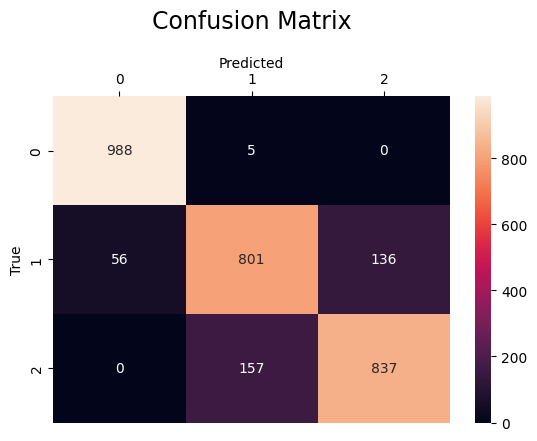

Test Loss: 0.2742, Test Accuracy: 0.8812


In [24]:
# Load the best model for testing

model.load_state_dict(torch.load("VGG_best_model.pth"))
test_loss = test_loop(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss[0]:.4f}, Test Accuracy: {test_loss[1]:.4f}")

Test Loss: 0.2525, Accuracy: 0.8888
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      4766
           1       0.85      0.81      0.83      4552
           2       0.86      0.86      0.86      4588

    accuracy                           0.89     13906
   macro avg       0.89      0.89      0.89     13906
weighted avg       0.89      0.89      0.89     13906


Test metrics:
Class 0:
  TP=4748, FP=255, FN=18
  Precision = TP / (TP + FP) = 4748 / (4748 + 255) = 0.9490
  Recall    = TP / (TP + FN) = 4748 / (4748 + 18) = 0.9962
  F1        = 2 * (P*R)/(P+R) = 2*(0.9490*0.9962)/(0.9490+0.9962) = 0.9721
Class 1:
  TP=3677, FP=671, FN=875
  Precision = TP / (TP + FP) = 3677 / (3677 + 671) = 0.8457
  Recall    = TP / (TP + FN) = 3677 / (3677 + 875) = 0.8078
  F1        = 2 * (P*R)/(P+R) = 2*(0.8457*0.8078)/(0.8457+0.8078) = 0.8263
Class 2:
  TP=3935, FP=620, FN=653
  Precision = TP / (TP + FP) = 3935 / (3935 + 620) = 0.8639
  Recall    = T

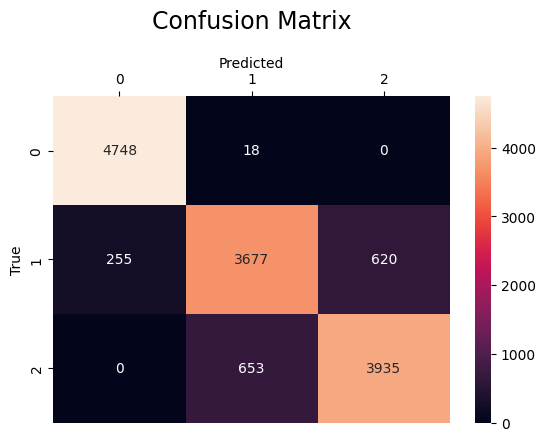

Train Loss: 0.2525, Train Accuracy: 0.8888


In [25]:
# Load the best model for testing

model.load_state_dict(torch.load("VGG_best_model.pth"))
train_loss = test_loop(model, train_loader, criterion, device)
print(f"Train Loss: {train_loss[0]:.4f}, Train Accuracy: {train_loss[1]:.4f}")

Test Loss: 0.2802, Accuracy: 0.8809
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       993
           1       0.84      0.79      0.82       994
           2       0.84      0.86      0.85       993

    accuracy                           0.88      2980
   macro avg       0.88      0.88      0.88      2980
weighted avg       0.88      0.88      0.88      2980


Test metrics:
Class 0:
  TP=988, FP=48, FN=5
  Precision = TP / (TP + FP) = 988 / (988 + 48) = 0.9537
  Recall    = TP / (TP + FN) = 988 / (988 + 5) = 0.9950
  F1        = 2 * (P*R)/(P+R) = 2*(0.9537*0.9950)/(0.9537+0.9950) = 0.9739
Class 1:
  TP=787, FP=148, FN=207
  Precision = TP / (TP + FP) = 787 / (787 + 148) = 0.8417
  Recall    = TP / (TP + FN) = 787 / (787 + 207) = 0.7918
  F1        = 2 * (P*R)/(P+R) = 2*(0.8417*0.7918)/(0.8417+0.7918) = 0.8160
Class 2:
  TP=850, FP=159, FN=143
  Precision = TP / (TP + FP) = 850 / (850 + 159) = 0.8424
  Recall    = TP / (TP + FN) = 8

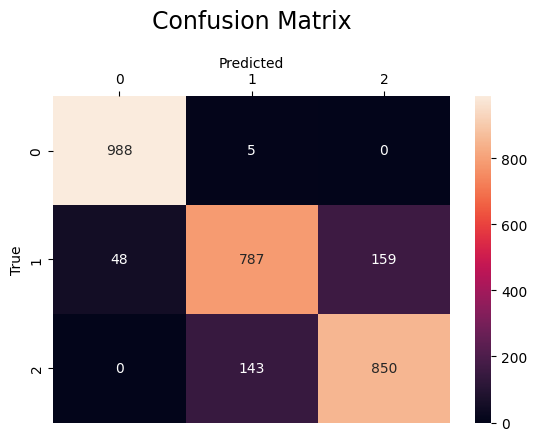

Test Loss: 0.2802, Test Accuracy: 0.8809


In [26]:
# Load the best model for testing

model.load_state_dict(torch.load("VGG_best_model.pth"))
val_loss = test_loop(model, val_loader, criterion, device)
print(f"Test Loss: {val_loss[0]:.4f}, Test Accuracy: {val_loss[1]:.4f}")